
<html>
<body>




<p align="center">
<img src="https://ensias.um5.ac.ma/sites/ensias.um5.ac.ma/files/logo5_0.jpg" alt="logo ensias" width="120" height="140"/></p>

<p align="center"><b><font size="5">Tutorial: Régression polynômiale </font></b></p>



---


<br>
<font size="2">
<b>Élément de module :</b>	Deep learning<br>	
<b>Année universitaire :</b>	2019-2020<br>
<b>Semestre :</b>	
</font>		


---

<font size="2">
<I>Pr. Aissam BERRAHOU</I></font>
<br>
<br>


</body>
</html>


<font size="2">
La régression a pour objectif d’expliquer une variable Y par une autre variable X. Par exemple on peut expliquer les performances d’un athlète par la durée de son entrainement ou même  le salaire d’une personne par le nombre d’années passées à l’université. Dans notre cas on s’intéresse à la régression linéaire multiple qui modélise la relation entre X(ensembles de variables explicatives) et Y par une équation linéaire.
</font>


**Traitements réalisés** :<br>
<font size="2">
* Création d'une base de données
* Splitting de la base de données
* Visualisation de la base de donnée
* Recherche des paramètres du modèle
* Evaluation du modèle par la méthode d'analyse de la variance
* Choix du degré du polynôme
</font>


# <font color="red" size="4"><b>1. Création d'une base de données</font>


In [7]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression,SGDRegressor
import matplotlib.pyplot as plt


In [8]:

#x,y=make_regression(n_samples=n_observations,n_features=1, noise=10)
x = np.array([1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22])
y = np.array([100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100])
n_observations=len(y)
x=x.reshape(n_observations,1)
y=y.reshape(n_observations,1)
print(np.shape(x))
print(y.shape)

(18, 1)
(18, 1)


 <font color="blue" size="3">a. Spiliting de la base de données en deux sous-ensembles(Apprentissage et Test)</font>

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

 <font color="blue" size="3">b. Visualisation des deux sous-ensembles(Apprentissage et Test)</font>

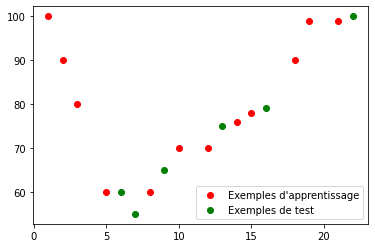

In [10]:
plt.scatter(x_train,y_train, c='r',label="Exemples d'apprentissage")
plt.scatter(x_test,y_test, c='green',label='Exemples de test')
plt.legend()

# <font color="red" size="4"><b>2. Recherche des paramètres du modèle avec sckitlearn</font>

## <font color="blue" size="3">a. Déterminer le degré du polynôme</font>

In [11]:
poly = PolynomialFeatures(degree=3, include_bias=True)


## <font color="blue" size="3">b. Transformer les observations de la variable explicative </font>

In [12]:
x_train_poly = poly.fit_transform(x_train)


In [13]:
x_train

array([[14],
       [18],
       [12],
       [ 8],
       [10],
       [19],
       [ 2],
       [15],
       [ 5],
       [ 3],
       [21],
       [ 1]])

In [14]:
x_train_poly

array([[1.000e+00, 1.400e+01, 1.960e+02, 2.744e+03],
       [1.000e+00, 1.800e+01, 3.240e+02, 5.832e+03],
       [1.000e+00, 1.200e+01, 1.440e+02, 1.728e+03],
       [1.000e+00, 8.000e+00, 6.400e+01, 5.120e+02],
       [1.000e+00, 1.000e+01, 1.000e+02, 1.000e+03],
       [1.000e+00, 1.900e+01, 3.610e+02, 6.859e+03],
       [1.000e+00, 2.000e+00, 4.000e+00, 8.000e+00],
       [1.000e+00, 1.500e+01, 2.250e+02, 3.375e+03],
       [1.000e+00, 5.000e+00, 2.500e+01, 1.250e+02],
       [1.000e+00, 3.000e+00, 9.000e+00, 2.700e+01],
       [1.000e+00, 2.100e+01, 4.410e+02, 9.261e+03],
       [1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00]])

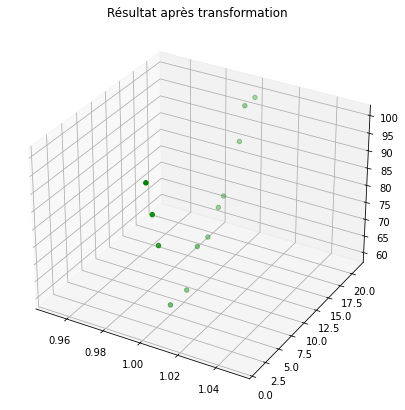

In [15]:
fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")
 
# Creating plot
ax.scatter3D(x_train_poly[:,0], x_train_poly[:,1], y_train, color = "green")
plt.title("Résultat après transformation")
 
# show plot
plt.show()

## <font color="blue" size="3">c. Instanciation d'un modèle linéaire </font>

In [16]:
#lin_reg_2 = LinearRegression() 
lin_reg_2=SGDRegressor()


## <font color="blue" size="3">d. Apprentissage du modèle sur les exemples d'apprentissage </font>

In [17]:
lin_reg_2.fit(x_train_poly, y_train)
print("les paramètres du modèle:",lin_reg_2.coef_,lin_reg_2.intercept_)

les paramètres du modèle: [-3.47633928e+10 -3.01196411e+11 -2.16970900e+12  7.46808269e+11] [-3.47623615e+10]


c:\RoboDK\Python37\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## <font color="blue" size="3">b. Visualisation du modèle de régression</font>

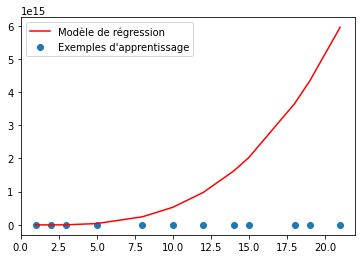

In [18]:
import operator
y_pred_train=lin_reg_2.predict(x_train_poly)


sort_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x_train,y_pred_train), key=sort_axis)
x_p, y_poly_pred_P = zip(*sorted_zip)
plt.scatter(x_train,y_train,label="Exemples d'apprentissage")
plt.plot(x_p,y_poly_pred_P,c='r',label="Modèle de régression")
plt.legend()

# <font color="red" size="4"><b>6. Evaluation du modèle sur l'ensemble de test par la méthode d'analyse de la variance </font>

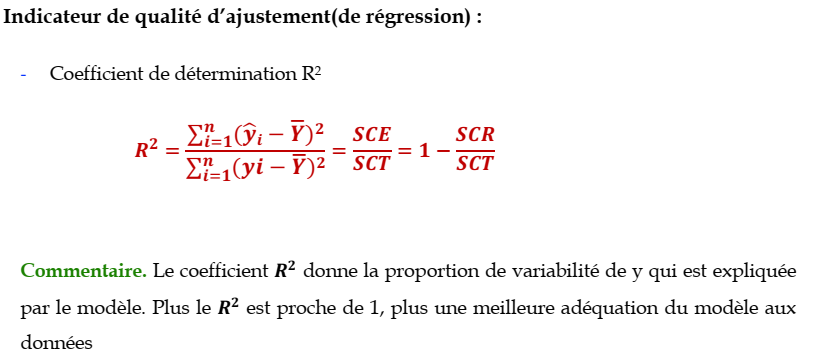

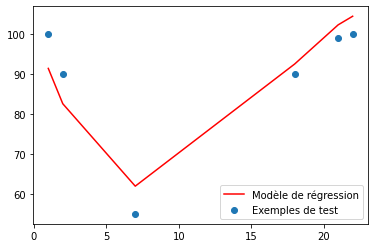

In [105]:


x_test_poly = poly.fit_transform(x_test)
y_pred_test=lin_reg_2.predict(x_test_poly)



sort_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x_test,y_pred_test), key=sort_axis)
x_p, y_poly_pred_P = zip(*sorted_zip)
plt.scatter(x_test,y_test,label="Exemples de test")
plt.plot(x_p,y_poly_pred_P,c='r',label="Modèle de régression")
plt.legend()
plt.show()

In [106]:

def coefficient_determination(y,y_pr):
  SCT=((y-y.mean())**2).sum()
  SCR=((y_pr-y)**2).sum()

  return 1- (SCR/SCT)

print("r2 d'apprentissage: ",coefficient_determination(y_train,y_pred_train))

print("r2 de test: ",coefficient_determination(y_test,y_pred_test))


r2 d'apprentissage:  0.882006471301457
r2 de test:  0.8570310277004497


# <font color="red" size="4"><b>7. Choix du degré de polynôme</font>

In [62]:
from sklearn.metrics import mean_squared_error
def evaluation_metriques(y_true,y_pred):
    return {"r2":coefficient_determination(y_true,y_pred), "MSE":mean_squared_error(y_true,y_pred)}

In [63]:
def choixDegree(degree):
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    
    
    x_train_poly = poly.fit_transform(x_train)
    lin_reg_2 = LinearRegression()
    lin_reg_2.fit(x_train_poly,y_train)
    y_pred_train=lin_reg_2.predict(x_train_poly)

    x_test_poly = poly.fit_transform(x_test)
    y_pred_test=lin_reg_2.predict(x_test_poly)

    return evaluation_metriques(y_train,y_pred_train),evaluation_metriques(y_test,y_pred_test)

In [93]:
listMetTrain=[]
listMetTest=[]

for i in range(1,5):

    metriqueTr,metriqueTe=choixDegree(i)
    listMetTrain.append(metriqueTr)
    listMetTest.append(metriqueTe)
    

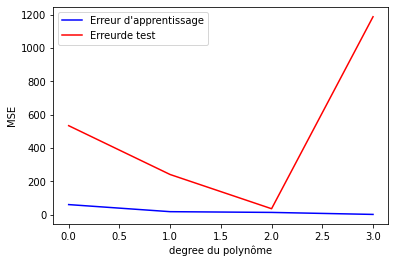

In [100]:
plt.plot([dic['MSE'] for dic in listMetTrain],c="b",label="Erreur d'apprentissage")
plt.plot([dic['MSE'] for dic in listMetTest],c="r",label="Erreur de test")
plt.xlabel("degree du polynôme")
plt.ylabel("MSE")
plt.legend()
plt.show()

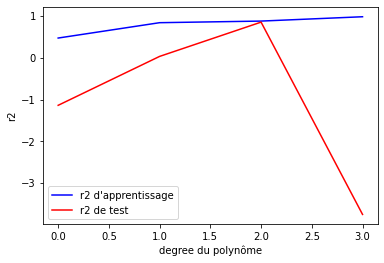

In [101]:
plt.plot([dic['r2'] for dic in listMetTrain],c="b",label="r2 d'apprentissage")
plt.plot([dic['r2'] for dic in listMetTest],c="r",label="r2 de test")
plt.xlabel("degree du polynôme")
plt.ylabel("r2")
plt.legend()
plt.show()